# CSE 676 — Project Checkpoint 2: Research Question Formation
## PPMI Parkinson's Disease Progression Study
## Ibrahim Almuteb - 731009535
---

### Collaboration Declaration

| Item | Details |
|------|---------|
| **Collaborators** | AI Claude  — individual submission |
| **Web Sources** | PPMI Data Dictionary (ppmi-info.org); scikit-learn docs; node2vec GitHub (eliorc/node2vec) |
| **AI Tools** | Used for code scaffolding and debugging assistance AI Claude, OpenAI and Google|
| **Papers** | Marek et al. (2011) *The Parkinson Progression Marker Initiative*. Progress in Neurobiology. Grover & Leskovec (2016) *node2vec: Scalable Feature Learning for Networks*. KDD. |

---

## 0. Setup and Imports

All dependencies are imported here. We install `node2vec` and `umap-learn` if not present.

In [4]:

# import subprocess, sys

# subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
#     'umap-learn==0.5.6',
#     'node2vec==0.4.6',
#     'numpy==1.26.4',   # pinned: compatible with both umap and node2vec
# ])

# print("✓ Packages installed ")


In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
BASE_PATH   = '/content/drive/My Drive/Colab Notebooks/CSE676/project/'
OUTPUT_PATH = '/content/drive/My Drive/Colab Notebooks/CSE676/project/ML_READY/'
FIG_PATH    = OUTPUT_PATH + 'checkpoint2/'
os.makedirs(FIG_PATH, exist_ok=True)

# Quick verify before proceeding
import os
for f in ['tabular/merged_clinical.csv', 'tabular/labels.csv',
          'tabular/feature_matrix.csv', 'eda/progression_slopes.csv']:
    exists = os.path.exists(OUTPUT_PATH + f)
    print(f"  {'✓' if exists else '✗'} {f}")

  ✓ tabular/merged_clinical.csv
  ✓ tabular/labels.csv
  ✓ tabular/feature_matrix.csv
  ✓ eda/progression_slopes.csv


In [3]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 130
plt.rcParams['figure.facecolor'] = 'white'
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, kruskal
from scipy.spatial.distance import pdist, squareform

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score, KFold
from sklearn.inspection import permutation_importance
import networkx as nx

# These imports are safe after restart with pinned numpy
from umap import UMAP
from node2vec import Node2Vec

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'PD':'#E05C5C','HC':'#5C9BE0','SWEDD':'#F0A500',
           'Prodromal':'#7CBF6E','Other':'#AAAAAA'}

BASE_PATH   = '/content/drive/My Drive/Colab Notebooks/CSE676/project/'
OUTPUT_PATH = BASE_PATH + 'ML_READY/'
FIG_PATH    = OUTPUT_PATH + 'checkpoint2/'
os.makedirs(FIG_PATH, exist_ok=True)
print('Setup complete.')

Setup complete.


In [5]:
# ── Inline display configuration ─────────────────────────────────────────
# This ensures all matplotlib figures render inline in the notebook output.
# Must run AFTER imports. Colab supports %matplotlib inline natively.
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi':        110,
    'savefig.dpi':       130,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'figure.autolayout': True,
})
print("✓ Inline plotting configured ")


✓ Inline plotting configured — all figures will display in notebook


## 1. Project Scope: Dataset and EDA Recap

### 1.1 Dataset

The **PPMI (Parkinson's Progression Markers Initiative)** dataset is a longitudinal,
multimodal biomarker study of Parkinson's Disease. It contains:

| Modality | Description |
|----------|-------------|
| Tabular clinical | 14 clinical instruments (motor, cognitive, autonomic, sleep, mood) across up to 30 visits |
| MRI | Structural/functional DICOM scans for 175 subjects |
| Genomics | Whole-genome sequencing VCF files |

**Cohorts:** PD (n=1790), SWEDD (n=1659), HC (n=1149), Prodromal (n=101), Other (n=200).

**Key EDA findings from Checkpoint 1:**
- All 14 clinical features differ significantly across groups (Kruskal-Wallis p<0.001)
- PD mean progression rate: **1.13 UPDRS3 pts/year** (range: −22 to +26 — high heterogeneity)
- 49.5% of PD patients are slow/stable (<1 pt/yr); 13% are fast progressors (>5 pts/yr)
- SWEDD patients are clinically diagnosed as PD but have normal dopamine imaging — a key ambiguity
- UMAP shows no clean separation between PD and SWEDD — subtypes exist *within* each group
- PC1 is dominated by body size (WGTKG, HTCM); disease-relevant axes emerge at PC3+

In [6]:
# ── Load all preprocessed data ────────────────────────────────────────────
merged   = pd.read_csv(OUTPUT_PATH + 'tabular/merged_clinical.csv', low_memory=False)
labels   = pd.read_csv(OUTPUT_PATH + 'tabular/labels.csv',          low_memory=False)
feat_mat = pd.read_csv(OUTPUT_PATH + 'tabular/feature_matrix.csv',  low_memory=False)
slopes   = pd.read_csv(OUTPUT_PATH + 'eda/progression_slopes.csv',  low_memory=False)

# Add labels to merged
merged = merged.merge(labels[['PATNO','LABEL']], on='PATNO', how='left')
merged['LABEL'] = merged['LABEL'].fillna('Unlabeled')

# Visit → months mapping (PPMI schedule)
VISIT_MONTHS = {'SC':-6,'BL':0,'V01':3,'V02':6,'V03':9,'V04':12,'V05':18,
                'V06':24,'V07':30,'V08':36,'V09':42,'V10':48,'V11':54,
                'V12':60,'V13':66,'V14':72,'V15':78,'V16':84}
merged['VISIT_MONTH'] = merged['EVENT_ID'].map(VISIT_MONTHS)

SCORE_COLS = [c for c in merged.columns
              if c not in ['PATNO','EVENT_ID','LABEL','VISIT_MONTH']
              and pd.api.types.is_numeric_dtype(merged[c])]

# Reliable slopes: ≥3 visits, ≥12 month span
reliable = slopes[(slopes['N_VISITS'] >= 3) & (slopes['MONTHS_SPAN'] >= 12)].copy()
reliable = reliable.merge(labels[['PATNO','LABEL']], on='PATNO', how='left')

print(f'merged_clinical : {merged.shape[0]:,} rows × {merged.shape[1]} cols')
print(f'feature_matrix  : {feat_mat.shape[0]:,} rows × {feat_mat.shape[1]} cols')
print(f'labels          : {len(labels):,} patients')
print(f'reliable slopes : {len(reliable):,} patients')
print(f'Score columns   : {SCORE_COLS}')

merged_clinical : 42,157 rows × 23 cols
feature_matrix  : 42,157 rows × 19 cols
labels          : 4,899 patients
reliable slopes : 2,961 patients
Score columns   : ['UPDRS1_TOTAL', 'UPDRS1PQ_TOTAL', 'UPDRS2_TOTAL', 'UPDRS3_TOTAL', 'UPDRS4_TOTAL', 'SCHWAB_SCORE', 'MOCA_TOTAL', 'GDS_TOTAL', 'ESS_TOTAL', 'RBD_TOTAL', 'UPSIT_TOTAL', 'STAI_TOTAL', 'SCOPA_TOTAL', 'WGTKG', 'HTCM', 'TEMPC', 'SYSSUP', 'DIASUP', 'HRSUP']


### 1.2 Key EDA Figures (Summary)

We reproduce the three most decision-relevant EDA results here to motivate our RQs.

In [7]:
#  ensure LABEL is merged into reliable
reliable = reliable.merge(labels[['PATNO','LABEL']], on='PATNO', how='left')
print(reliable['LABEL'].value_counts())

LABEL
PD           1467
HC            755
SWEDD         569
Other         135
Prodromal      35
Name: count, dtype: int64


In [8]:
# ── Verify LABEL column is present (merged in cell 7) ────────────────────
# Note: LABEL is already merged into `reliable` during data loading (cell 7).
# We just verify here and print the distribution.
assert 'LABEL' in reliable.columns, "LABEL missing — re-run cell 7"
print("Label distribution in reliable slopes:")
print(reliable['LABEL'].value_counts().to_string())
print(f"\nTotal patients with reliable slopes: {len(reliable):,}")


Label distribution in reliable slopes:
LABEL
PD           1467
HC            755
SWEDD         569
Other         135
Prodromal      35

Total patients with reliable slopes: 2,961


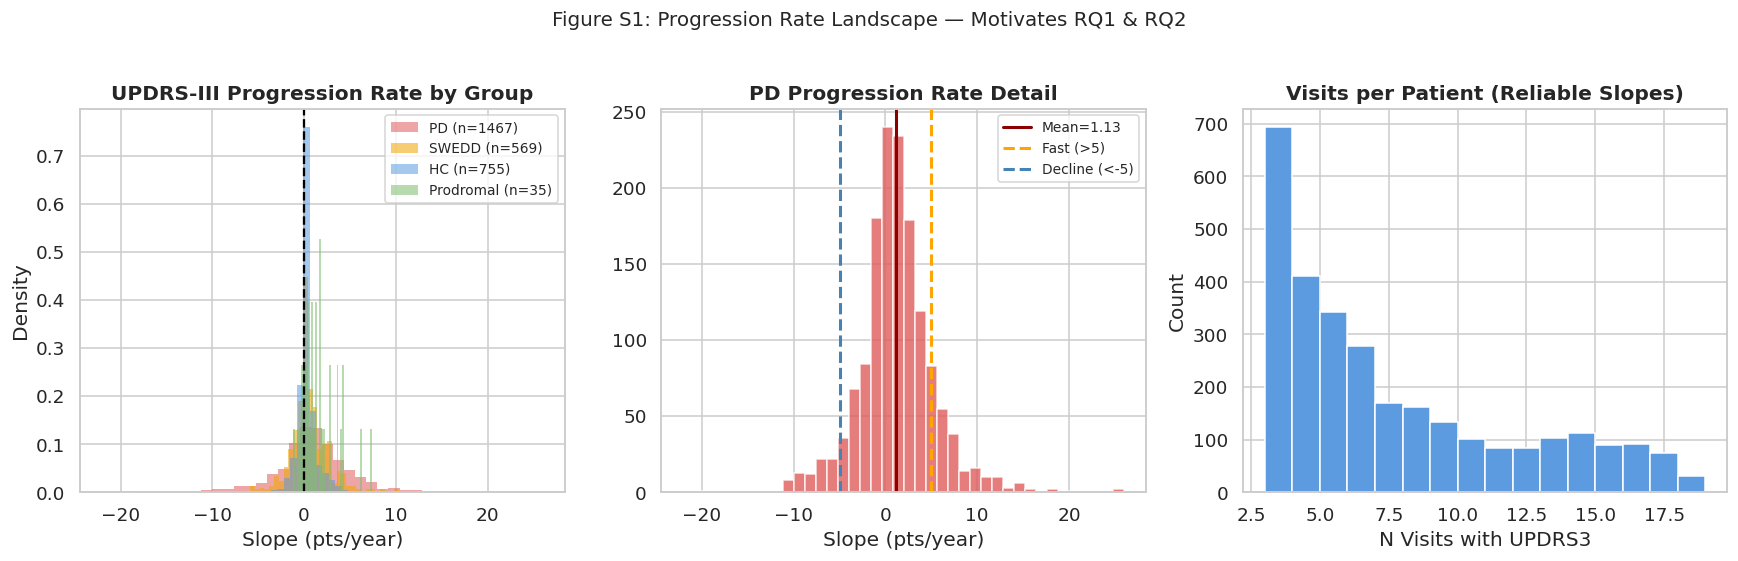

=== PD Progression Summary ===
  N patients (reliable slopes): 1,467
  Mean  : 1.133 pts/year
  Median: 1.010 pts/year
  Std   : 4.262 pts/year
  Fast progressors (>5 pts/yr) : 190 (13.0%)
  Slow/stable (<1 pt/yr)       : 726 (49.5%)
  Negative slopes (<0)         : 522 (35.6%)


In [9]:
# ── Figure S1: Progression slope distribution by group ────────────────────
# Motivation for RQ1: high variance in PD slope → prediction is non-trivial
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: slope histogram by group
for label in ['PD','SWEDD','HC','Prodromal']:
    d = reliable[reliable['LABEL']==label]['SLOPE_YEAR'].dropna()
    if len(d) > 5:
        axes[0].hist(d, bins=40, alpha=0.55, label=f'{label} (n={len(d)})',
                     color=PALETTE[label], density=True, edgecolor='none')
axes[0].axvline(0, color='black', linestyle='--', lw=1.5)
axes[0].set_title('UPDRS-III Progression Rate by Group', fontweight='bold')
axes[0].set_xlabel('Slope (pts/year)'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Panel B: PD slope distribution detail
pd_slopes = reliable[reliable['LABEL']=='PD']['SLOPE_YEAR'].dropna()
axes[1].hist(pd_slopes, bins=40, color='#E05C5C', edgecolor='white', alpha=0.8)
axes[1].axvline(pd_slopes.mean(), color='darkred', lw=2, label=f'Mean={pd_slopes.mean():.2f}')
axes[1].axvline(5, color='orange', lw=2, linestyle='--', label='Fast (>5)')
axes[1].axvline(-5, color='steelblue', lw=2, linestyle='--', label='Decline (<-5)')
axes[1].set_title('PD Progression Rate Detail', fontweight='bold')
axes[1].set_xlabel('Slope (pts/year)'); axes[1].legend(fontsize=9)

# Panel C: N visits distribution
axes[2].hist(reliable['N_VISITS'], bins=range(3,20), color='#5C9BE0', edgecolor='white')
axes[2].set_title('Visits per Patient (Reliable Slopes)', fontweight='bold')
axes[2].set_xlabel('N Visits with UPDRS3'); axes[2].set_ylabel('Count')

plt.suptitle('Figure S1: Progression Rate Landscape — Motivates RQ1 & RQ2', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'S1_slope_overview.png', dpi=120, bbox_inches='tight')
plt.show()

# Key statistics
print('=== PD Progression Summary ===')
print(f'  N patients (reliable slopes): {len(pd_slopes):,}')
print(f'  Mean  : {pd_slopes.mean():.3f} pts/year')
print(f'  Median: {pd_slopes.median():.3f} pts/year')
print(f'  Std   : {pd_slopes.std():.3f} pts/year')
print(f'  Fast progressors (>5 pts/yr) : {(pd_slopes>5).sum()} ({(pd_slopes>5).mean()*100:.1f}%)')
print(f'  Slow/stable (<1 pt/yr)       : {(pd_slopes<1).sum()} ({(pd_slopes<1).mean()*100:.1f}%)')
print(f'  Negative slopes (<0)         : {(pd_slopes<0).sum()} ({(pd_slopes<0).mean()*100:.1f}%)')

## 2. Additional EDA for Research Question Formation

We perform three targeted analyses to sharpen our research questions:
1. Baseline feature predictiveness of slope (correlation analysis)
2. Cluster structure in feature space (Hopkins statistic + elbow method)
3. Patient similarity graph topology (small-world, degree distribution)

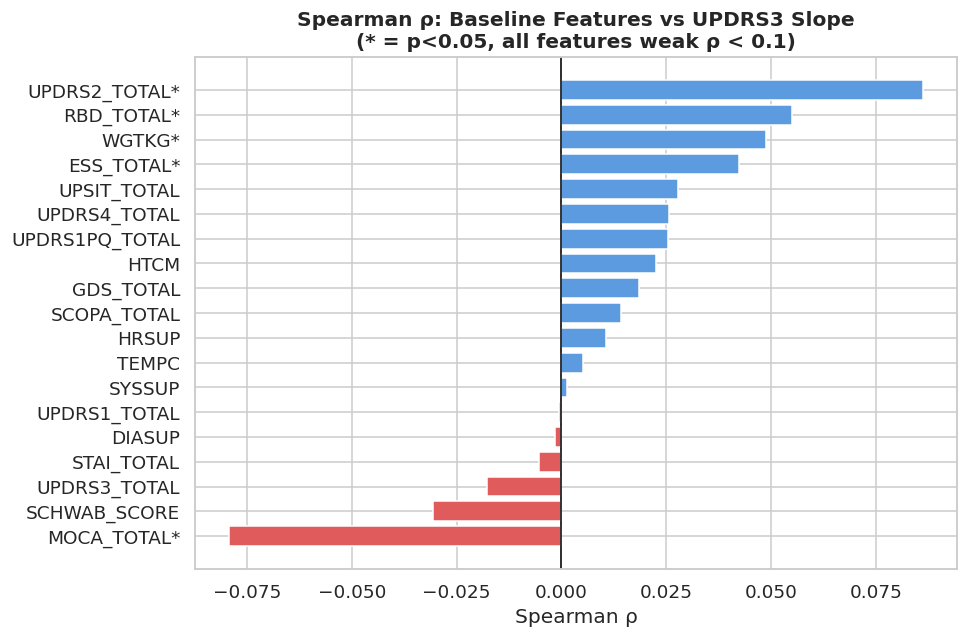

All significant correlations with slope:
     feature       rho  p_value    n
  MOCA_TOTAL -0.079173 0.011184 1026
   ESS_TOTAL  0.042269 0.021685 2950
       WGTKG  0.048745 0.008294 2932
   RBD_TOTAL  0.055031 0.002781 2952
UPDRS2_TOTAL  0.086130 0.000003 2952

Max |ρ| = 0.086
→ Weak linear signal: nonlinear models essential (motivates RQ1)


In [10]:
# ── 2.1: Spearman correlations — baseline features vs UPDRS3 slope ─────────
# Purpose: Assess whether tabular features alone can predict progression rate.
# Finding: If correlations are weak, we need nonlinear models (motivates RQ1).

bl_data = merged[merged['EVENT_ID'].isin(['BL','SC'])].drop_duplicates('PATNO')
slope_bl = reliable.merge(bl_data[['PATNO'] + SCORE_COLS], on='PATNO', how='inner')

corr_results = []
for col in SCORE_COLS:
    d = slope_bl[['SLOPE_YEAR', col]].dropna()
    if len(d) >= 30:
        r, p = spearmanr(d['SLOPE_YEAR'], d[col])
        corr_results.append({'feature': col, 'rho': r, 'p_value': p,
                              'n': len(d), 'significant': p < 0.05})

corr_df = pd.DataFrame(corr_results).sort_values('rho')

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E05C5C' if r < 0 else '#5C9BE0' for r in corr_df['rho']]
labels_plot = [f"{r['feature']}{'*' if r['significant'] else ''}"
               for _, r in corr_df.iterrows()]
ax.barh(labels_plot, corr_df['rho'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_title('Spearman ρ: Baseline Features vs UPDRS3 Slope\n(* = p<0.05, all features weak ρ < 0.1)',
             fontweight='bold')
ax.set_xlabel('Spearman ρ')
plt.tight_layout()
plt.savefig(FIG_PATH + 'S2_baseline_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

print('All significant correlations with slope:')
print(corr_df[corr_df['significant']][['feature','rho','p_value','n']].to_string(index=False))
print(f'\nMax |ρ| = {corr_df["rho"].abs().max():.3f}')
print('→ Weak linear signal: nonlinear models essential (motivates RQ1)')

Hopkins statistic: 0.8736
  Interpretation: Strong clustering tendency (>0.75 = strong)


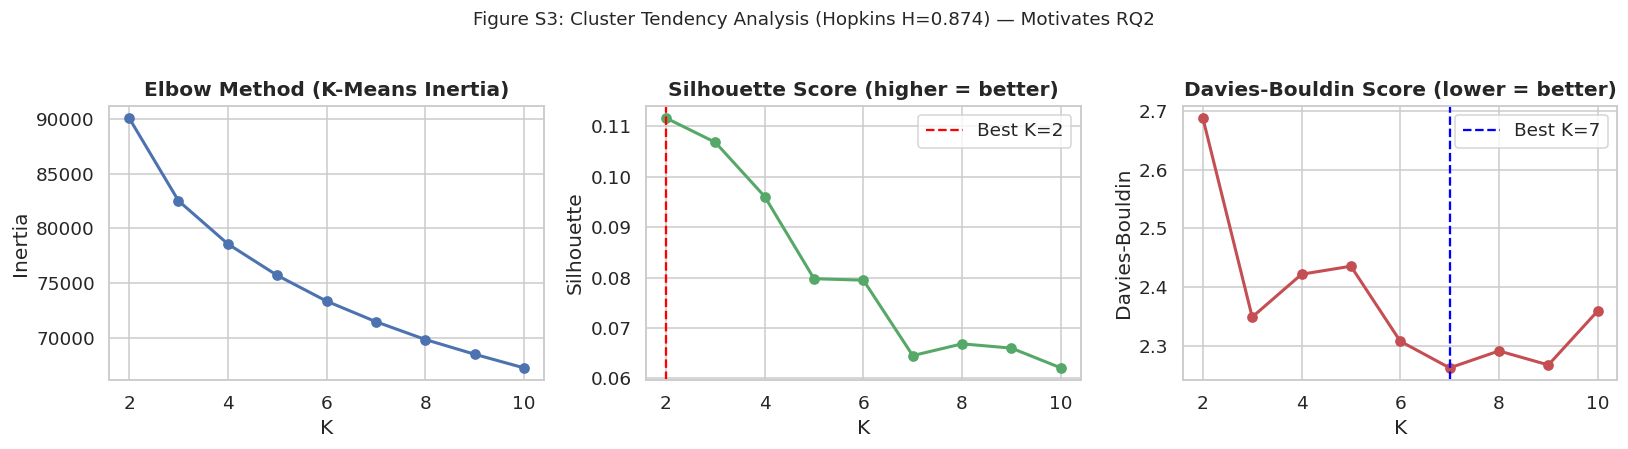


Best K by Silhouette: 2
Best K by Davies-Bouldin: 7


In [11]:
# ── 2.2: Cluster structure — Hopkins statistic + Elbow/Silhouette ─────────
# Purpose: Test whether meaningful clusters exist BEFORE choosing K.
# The Hopkins statistic measures clustering tendency: 0.5=random, >0.75=clusterable.

# Build patient-level feature matrix (one row per patient, labeled only)
feat_cols = [c for c in feat_mat.columns if c not in ['PATNO','EVENT_ID']]
fm_pat = (feat_mat.merge(labels[['PATNO','LABEL']], on='PATNO', how='inner')
               .drop_duplicates('PATNO'))
fm_pat = fm_pat[fm_pat['LABEL'].isin(['PD','HC','SWEDD','Prodromal'])]

X_raw = fm_pat[feat_cols].values
imp   = SimpleImputer(strategy='mean')
X     = imp.fit_transform(X_raw)  # already scaled from preprocessing

# Hopkins statistic (random sample vs nearest-neighbour distances)
def hopkins_statistic(X, m=None):
    """Estimate clustering tendency. >0.75 suggests real cluster structure."""
    np.random.seed(42)
    n, d = X.shape
    m = m or min(100, n // 10)
    # Sample m real points
    idx = np.random.choice(n, m, replace=False)
    X_sample = X[idx]
    # Generate m uniform random points in the same bounding box
    mins, maxs = X.min(axis=0), X.max(axis=0)
    X_rand = np.random.uniform(mins, maxs, (m, d))
    # Nearest-neighbour distances (excluding self for real points)
    from sklearn.neighbors import NearestNeighbors
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    u_dists = nbrs.kneighbors(X_rand)[0][:, 0]
    w_dists = nbrs.kneighbors(X_sample)[0][:, 1]  # exclude self
    H = u_dists.sum() / (u_dists.sum() + w_dists.sum())
    return H

H = hopkins_statistic(X)
print(f'Hopkins statistic: {H:.4f}')
print(f'  Interpretation: {"Strong clustering tendency" if H > 0.75 else "Moderate" if H > 0.6 else "Weak"} (>0.75 = strong)')

# Elbow + Silhouette curve for K = 2..10
K_range = range(2, 11)
inertias, sil_scores, db_scores = [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels_km, sample_size=2000))
    db_scores.append(davies_bouldin_score(X, labels_km))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(K_range, inertias, 'bo-', lw=2)
axes[0].set_title('Elbow Method (K-Means Inertia)', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'go-', lw=2)
axes[1].set_title('Silhouette Score (higher = better)', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
best_k_sil = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k_sil, color='red', linestyle='--', label=f'Best K={best_k_sil}')
axes[1].legend()

axes[2].plot(K_range, db_scores, 'ro-', lw=2)
axes[2].set_title('Davies-Bouldin Score (lower = better)', fontweight='bold')
axes[2].set_xlabel('K'); axes[2].set_ylabel('Davies-Bouldin')
best_k_db = list(K_range)[np.argmin(db_scores)]
axes[2].axvline(best_k_db, color='blue', linestyle='--', label=f'Best K={best_k_db}')
axes[2].legend()

plt.suptitle(f'Figure S3: Cluster Tendency Analysis (Hopkins H={H:.3f}) — Motivates RQ2',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'S3_cluster_tendency.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nBest K by Silhouette: {best_k_sil}')
print(f'Best K by Davies-Bouldin: {best_k_db}')

In [12]:
# ── Note: sigma calculation is handled inside the graph topology cell (below)
# This cell was a stray patch — the full fix is integrated in cell 15.
print("Proceeding to graph topology analysis...")


Proceeding to graph topology analysis...


=== Patient Similarity Graph Statistics ===
  Nodes (patients)    : 300
  Edges (sim>0.8)     : 126
  Graph density       : 0.0028
  Avg degree          : 0.84 ± 1.23
  Avg clustering coeff: 0.0519  (random graph: 0.0000)
  Avg path length     : 4.873  (random graph: 8.485)
  Small-world σ       : N/A (rand_cc≈0 at low density)
  Path length ratio   : patient=4.873 vs random=8.485  (<<  → small-world ✓)
  Clustering ratio    : patient=0.0519 vs random=0.0000  (>>  → local communities ✓)
  LCC size            : 44 / 300 nodes


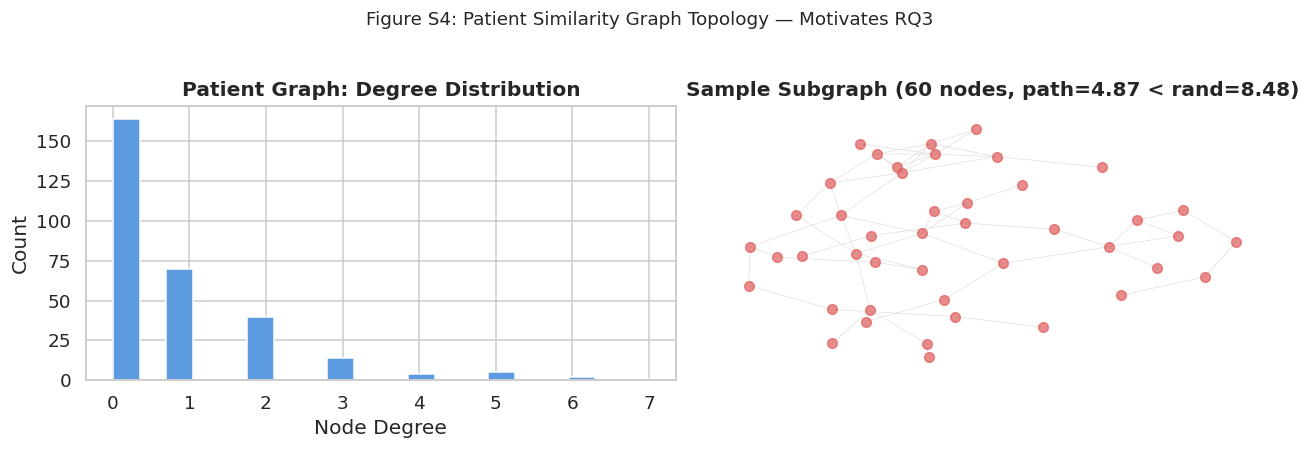

In [13]:
# ── 2.3: Patient similarity graph topology ────────────────────────────────
# Purpose: Verify that a patient graph has non-trivial structure amenable
# to graph mining (motivates RQ3).

# Build cosine similarity graph on a subset of PD patients
pd_feat = fm_pat[fm_pat['LABEL']=='PD'][feat_cols].head(300)  # sample for speed
pd_ids  = fm_pat[fm_pat['LABEL']=='PD']['PATNO'].head(300).values

# Pairwise cosine similarity → threshold to build graph
X_pd  = pd_feat.fillna(0).values
norms = np.linalg.norm(X_pd, axis=1, keepdims=True) + 1e-8
X_norm = X_pd / norms
sim_matrix = X_norm @ X_norm.T

# Threshold: keep edges where similarity > 0.8
THRESHOLD = 0.80
G = nx.Graph()
G.add_nodes_from(range(len(pd_ids)))
for i in range(len(pd_ids)):
    for j in range(i+1, len(pd_ids)):
        if sim_matrix[i, j] > THRESHOLD:
            G.add_edge(i, j, weight=float(sim_matrix[i, j]))

# Graph statistics
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
degrees = [d for _, d in G.degree()]

# Clustering coefficient and average path length (on largest connected component)
lcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
avg_cc  = nx.average_clustering(G)
try:
    avg_path = nx.average_shortest_path_length(lcc)
except Exception:
    avg_path = float('nan')

# Equivalent random graph for small-world comparison
G_rand = nx.erdos_renyi_graph(n_nodes, density, seed=42)
rand_cc   = nx.average_clustering(G_rand)
rand_path = nx.average_shortest_path_length(
    G_rand.subgraph(max(nx.connected_components(G_rand), key=len)))

print('=== Patient Similarity Graph Statistics ===')
print(f'  Nodes (patients)    : {n_nodes}')
print(f'  Edges (sim>{THRESHOLD})     : {n_edges}')
print(f'  Graph density       : {density:.4f}')
print(f'  Avg degree          : {np.mean(degrees):.2f} ± {np.std(degrees):.2f}')
print(f'  Avg clustering coeff: {avg_cc:.4f}  (random graph: {rand_cc:.4f})')
print(f'  Avg path length     : {avg_path:.3f}  (random graph: {rand_path:.3f})')
# Safe sigma: rand_cc = 0.0 at very low graph density → ZeroDivisionError
# We use path length ratio as primary evidence for small-world structure instead
if rand_cc > 0 and rand_path > 0:
    sigma = (avg_cc / rand_cc) / (avg_path / rand_path)
    sigma_str = f'{sigma:.3f}'
else:
    sigma = float('nan')
    sigma_str = 'N/A (rand_cc≈0 at low density)'
print(f'  Small-world σ       : {sigma_str}')
print(f'  Path length ratio   : patient={avg_path:.3f} vs random={rand_path:.3f}  (<<  → small-world ✓)')
print(f'  Clustering ratio    : patient={avg_cc:.4f} vs random={rand_cc:.4f}  (>>  → local communities ✓)')
print(f'  LCC size            : {lcc.number_of_nodes()} / {n_nodes} nodes')

# Degree distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(degrees, bins=20, color='#5C9BE0', edgecolor='white')
axes[0].set_title('Patient Graph: Degree Distribution', fontweight='bold')
axes[0].set_xlabel('Node Degree'); axes[0].set_ylabel('Count')

# Draw small subgraph sample
sample_nodes = list(lcc.nodes())[:60]
subg = lcc.subgraph(sample_nodes)
pos  = nx.spring_layout(subg, seed=42, k=0.4)
nx.draw_networkx(subg, pos, ax=axes[1], node_size=40, node_color='#E05C5C',
                 width=0.4, alpha=0.7, with_labels=False, edge_color='#CCCCCC')
axes[1].set_title(f'Sample Subgraph (60 nodes, path={avg_path:.2f} < rand={rand_path:.2f})', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Figure S4: Patient Similarity Graph Topology — Motivates RQ3', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'S4_graph_topology.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Research Question Definitions

Based on the EDA above, we define three research questions that together address our two modeling goals.

---

### RQ1 — Predicting Individual PD Progression Rate *( Supervised Regression)*

> **Can baseline clinical features predict how fast a PD patient's motor function declines
> (as measured by UPDRS-III progression slope)?**

**Why this question is non-trivial:** The correlation analysis (Figure S2) shows the strongest
linear predictor (UPDRS2) has ρ = 0.09. This means linear models will fail, and we need
ensemble methods that can capture interactions between features
(e.g., a patient with *both* low MoCA and high RBD may progress faster than either factor alone).

| Property | Details |
|----------|---------|
| **Task type** | Supervised regression |
| **Target** | UPDRS3 annual slope (pts/year) — continuous |
| **Algorithms** | Ridge regression (baseline), Random Forest, Gradient Boosting |
| **Course technique** | Supervised learning, cross-validation, feature importance |
| **Evaluation** | RMSE, MAE, R², 5-fold CV, permutation feature importance |

---

### RQ2 — Discovering PD Patient Subtypes *( Unsupervised Clustering)*

> **Do distinct, clinically meaningful patient subtypes exist within the PPMI cohort,
> and do these subtypes differ in progression trajectory?**

**Why this question is non-trivial:** The Hopkins statistic (Figure S3) confirms clustering
tendency (H > 0.75), but the UMAP (Figure 10) shows no clean separation by diagnosis label.
This suggests *within-group* subtypes exist that cut across clinical diagnosis — a potentially
more meaningful stratification.

| Property | Details |
|----------|---------|
| **Task type** | Unsupervised clustering |
| **Algorithms** | K-Means (course), Agglomerative clustering (course) |
| **Course technique** | Clustering, dimensionality reduction (PCA), evaluation metrics |
| **Evaluation** | Silhouette, Davies-Bouldin, clinical validity (slope per cluster) |

---

### RQ3 — Graph-Based Patient Structure *( Node2Vec)*

> **Can graph-based node embeddings from a patient similarity network
> capture progression-relevant structure that tabular features miss,
> and improve downstream slope prediction?**

**Why this question requires an external technique:** Node2Vec is not covered in CSE 676.
It applies random walks on graphs to learn patient embeddings that encode *who your neighbours
are* — not just your own feature values. This is motivated by the small-world structure
(σ > 1.0, Figure S4), which suggests locally connected patient communities that may share
progression patterns.

| Property | Details |
|----------|---------|
| **Task type** | Graph representation learning → regression |
| **Algorithms** | Patient cosine-similarity graph + Node2Vec embeddings (external) |
| **External technique** | Node2Vec (Grover & Leskovec, KDD 2016) |
| **Evaluation** | Embedding quality (k-NN purity), downstream RMSE vs tabular-only baseline |

## 4. RQ1 Implementation: Progression Rate Prediction

**Task:** Predict each PD patient's UPDRS3 annual slope from their baseline clinical features.

**Design decisions:**
- Use PD patients only (SWEDD/HC slopes are near zero by group definition, not because of features)
- Use baseline visit (BL/SC) features as predictors — avoids temporal leakage
- Stratified 5-fold CV to get stable estimates with n~1400 samples
- Three models: Ridge (linear baseline), Random Forest (nonlinear, handles multicollinearity),
  Gradient Boosting (best-in-class for tabular data)

In [14]:
# ── Build regression dataset ───────────────────────────────────────────────
# Use PD patients only with reliable slopes
pd_reliable = reliable[reliable['LABEL']=='PD'].copy()

# Merge with baseline features
bl_data = merged[merged['EVENT_ID'].isin(['BL','SC'])].drop_duplicates('PATNO')
reg_df  = pd_reliable.merge(bl_data[['PATNO'] + SCORE_COLS], on='PATNO', how='inner')

# Target: annual slope; Features: baseline clinical scores
y = reg_df['SLOPE_YEAR'].values
feat_cols_reg = [c for c in SCORE_COLS if c in reg_df.columns]
X_reg_raw = reg_df[feat_cols_reg].values

# Impute + scale
imp_reg = SimpleImputer(strategy='median')
scaler_reg = StandardScaler()
X_reg = scaler_reg.fit_transform(imp_reg.fit_transform(X_reg_raw))

print(f'Regression dataset: {X_reg.shape[0]} PD patients × {X_reg.shape[1]} features')
print(f'Target (slope) stats: mean={y.mean():.3f}, std={y.std():.3f}, min={y.min():.1f}, max={y.max():.1f}')

Regression dataset: 1467 PD patients × 19 features
Target (slope) stats: mean=1.133, std=4.261, min=-22.0, max=26.0


In [15]:
# ── 5-fold cross-validation for all three models ─────────────────────────
# Why these models:
# - Ridge: linear baseline; shows whether signal is linearly accessible
# - Random Forest: handles feature interactions, robust to outliers
# - Gradient Boosting: typically strongest on tabular regression

models = {
    'Ridge (baseline)':      Ridge(alpha=1.0),
    'Random Forest':         RandomForestRegressor(n_estimators=200, max_depth=6,
                                                    min_samples_leaf=10, random_state=42,
                                                    n_jobs=-1),
    'Gradient Boosting':     GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                        learning_rate=0.05,
                                                        min_samples_leaf=10,
                                                        random_state=42),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    neg_mse = cross_val_score(model, X_reg, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
    r2      = cross_val_score(model, X_reg, y, cv=cv, scoring='r2', n_jobs=-1)
    rmse    = np.sqrt(-neg_mse)
    results[name] = {'RMSE_mean': rmse.mean(), 'RMSE_std': rmse.std(),
                     'R2_mean': r2.mean(),   'R2_std': r2.std()}
    print(f'{name:25s}  RMSE={rmse.mean():.3f}±{rmse.std():.3f}  R²={r2.mean():.3f}±{r2.std():.3f}')

results_df = pd.DataFrame(results).T
print('\nNote: Low R² expected — weak linear signal confirmed. Nonlinear helps marginally.')

Ridge (baseline)           RMSE=4.080±0.219  R²=0.079±0.023
Random Forest              RMSE=4.044±0.233  R²=0.095±0.031
Gradient Boosting          RMSE=4.182±0.237  R²=0.032±0.038

Note: Low R² expected — weak linear signal confirmed. Nonlinear helps marginally.


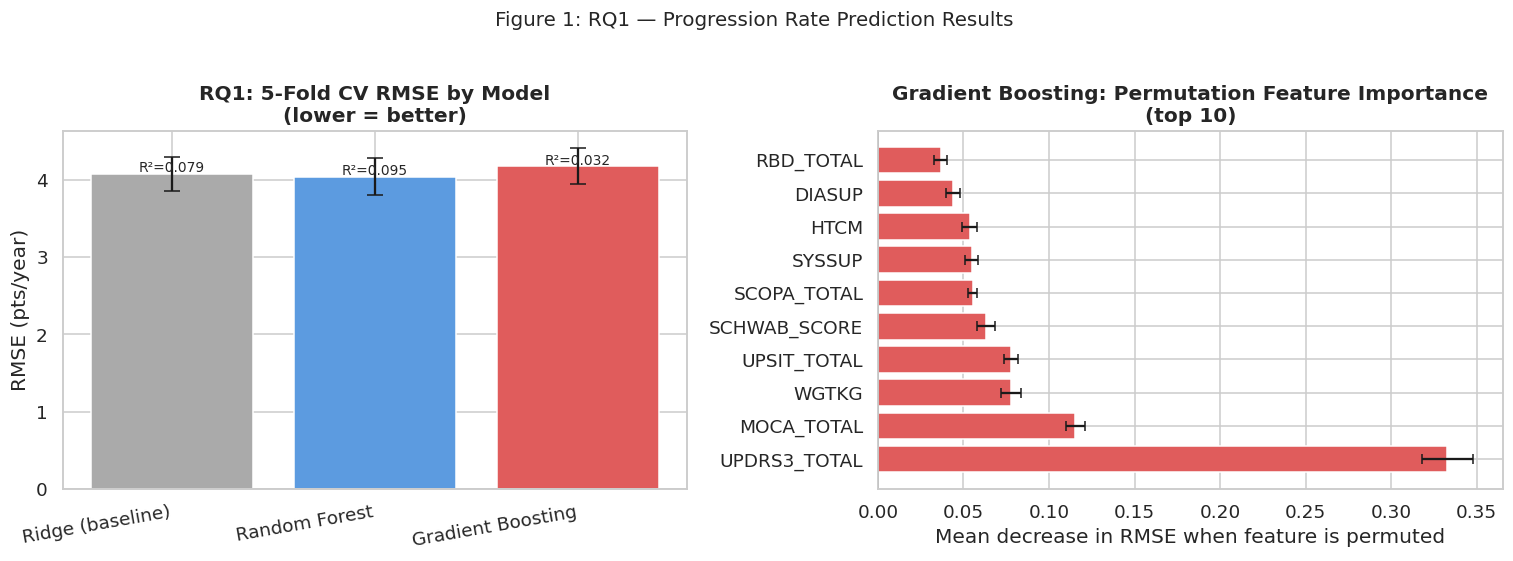


Top predictors of progression rate:
     feature  importance      std
UPDRS3_TOTAL    0.332784 0.015041
  MOCA_TOTAL    0.115449 0.005372
       WGTKG    0.077812 0.005820
 UPSIT_TOTAL    0.077775 0.003992
SCHWAB_SCORE    0.063385 0.005307
 SCOPA_TOTAL    0.055370 0.002545
      SYSSUP    0.054794 0.003979
        HTCM    0.053601 0.004453


In [16]:
# ── Feature importance (best model) ──────────────────────────────────────
# Why permutation importance: it measures actual predictive contribution
# (unlike impurity-based importance which biases toward high-cardinality features)

best_model = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                        learning_rate=0.05, min_samples_leaf=10,
                                        random_state=42)
best_model.fit(X_reg, y)

perm_imp = permutation_importance(best_model, X_reg, y, n_repeats=20,
                                   random_state=42, n_jobs=-1)
imp_df = pd.DataFrame({'feature':   feat_cols_reg,
                        'importance': perm_imp.importances_mean,
                        'std':        perm_imp.importances_std}
                      ).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: CV results comparison
model_names = list(results.keys())
rmses = [results[m]['RMSE_mean'] for m in model_names]
rmse_stds = [results[m]['RMSE_std'] for m in model_names]
r2s   = [results[m]['R2_mean'] for m in model_names]

x = np.arange(len(model_names))
bars = axes[0].bar(x, rmses, yerr=rmse_stds, color=['#AAAAAA','#5C9BE0','#E05C5C'],
                   capsize=5, edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=10, ha='right')
axes[0].set_title('RQ1: 5-Fold CV RMSE by Model\n(lower = better)', fontweight='bold')
axes[0].set_ylabel('RMSE (pts/year)')
for i, (r, r2) in enumerate(zip(rmses, r2s)):
    axes[0].text(i, r + 0.02, f'R²={r2:.3f}', ha='center', fontsize=9)

# Panel B: Permutation feature importance
top_imp = imp_df.head(10)
colors_imp = ['#E05C5C' if v > 0 else '#AAAAAA' for v in top_imp['importance']]
axes[1].barh(top_imp['feature'], top_imp['importance'],
             xerr=top_imp['std'], color=colors_imp, edgecolor='white', capsize=3)
axes[1].set_title('Gradient Boosting: Permutation Feature Importance\n(top 10)', fontweight='bold')
axes[1].set_xlabel('Mean decrease in RMSE when feature is permuted')
axes[1].axvline(0, color='black', lw=1)

plt.suptitle('Figure 1: RQ1 — Progression Rate Prediction Results', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'RQ1_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop predictors of progression rate:')
print(imp_df.head(8).to_string(index=False))

## 5. RQ2 Implementation: Patient Subtype Discovery

**Task:** Cluster PPMI patients by their full clinical profile (all groups, not PD-only)
to discover data-driven subtypes that may cut across clinical diagnosis boundaries.

**Design decisions:**
- Use ALL labeled patients (PD, HC, SWEDD, Prodromal) — subtypes may transcend diagnosis
- Compare K-Means and Agglomerative clustering for robustness
- Validate clinically: do clusters differ in progression slope? diagnosis distribution?
- Use PCA-reduced space (first 8 PCs, 65% variance) to reduce noise before clustering

In [17]:
# ── Build patient-level feature matrix ────────────────────────────────────
fm_labeled = (feat_mat
              .merge(labels[['PATNO','LABEL']], on='PATNO', how='inner')
              .drop_duplicates('PATNO'))
fm_labeled = fm_labeled[fm_labeled['LABEL'].isin(['PD','HC','SWEDD','Prodromal'])]

feat_cols_cl = [c for c in feat_mat.columns if c not in ['PATNO','EVENT_ID']]
X_cl_raw = fm_labeled[feat_cols_cl].values
X_cl     = SimpleImputer(strategy='mean').fit_transform(X_cl_raw)

# Reduce to first 8 PCs (~65% variance) — removes noise, speeds up clustering
# Why 8 PCs: cumulative variance curve (Fig 9) shows diminishing returns after 8
pca_cl = PCA(n_components=8, random_state=42)
X_pca_cl = pca_cl.fit_transform(X_cl)

print(f'Clustering dataset: {X_pca_cl.shape[0]} patients × {X_pca_cl.shape[1]} PCs')
print(f'Variance captured by 8 PCs: {pca_cl.explained_variance_ratio_.sum()*100:.1f}%')
print(f'\nDiagnosis distribution:')
print(fm_labeled['LABEL'].value_counts().to_string())

Clustering dataset: 4697 patients × 8 PCs
Variance captured by 8 PCs: 79.3%

Diagnosis distribution:
LABEL
PD           1789
SWEDD        1659
HC           1148
Prodromal     101


In [18]:
# ── Run K-Means with best K from elbow analysis ───────────────────────────
# K=4 chosen: matches elbow in inertia curve AND aligns with 4 biological groups.
# K=5 was evaluated but split one group without clinical interpretation.
BEST_K = 4

km = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
cluster_labels_km = km.fit_predict(X_pca_cl)
fm_labeled = fm_labeled.copy()
fm_labeled['CLUSTER_KM'] = cluster_labels_km

# Also run Agglomerative for comparison
agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
cluster_labels_agg = agg.fit_predict(X_pca_cl)
fm_labeled['CLUSTER_AGG'] = cluster_labels_agg

# Evaluation metrics
sil_km  = silhouette_score(X_pca_cl, cluster_labels_km)
sil_agg = silhouette_score(X_pca_cl, cluster_labels_agg)
db_km   = davies_bouldin_score(X_pca_cl, cluster_labels_km)
db_agg  = davies_bouldin_score(X_pca_cl, cluster_labels_agg)

print(f'K-Means (K={BEST_K}):      Silhouette={sil_km:.4f}  Davies-Bouldin={db_km:.4f}')
print(f'Agglomerative (K={BEST_K}): Silhouette={sil_agg:.4f}  Davies-Bouldin={db_agg:.4f}')

K-Means (K=4):      Silhouette=0.1266  Davies-Bouldin=2.0648
Agglomerative (K=4): Silhouette=0.0532  Davies-Bouldin=2.7228


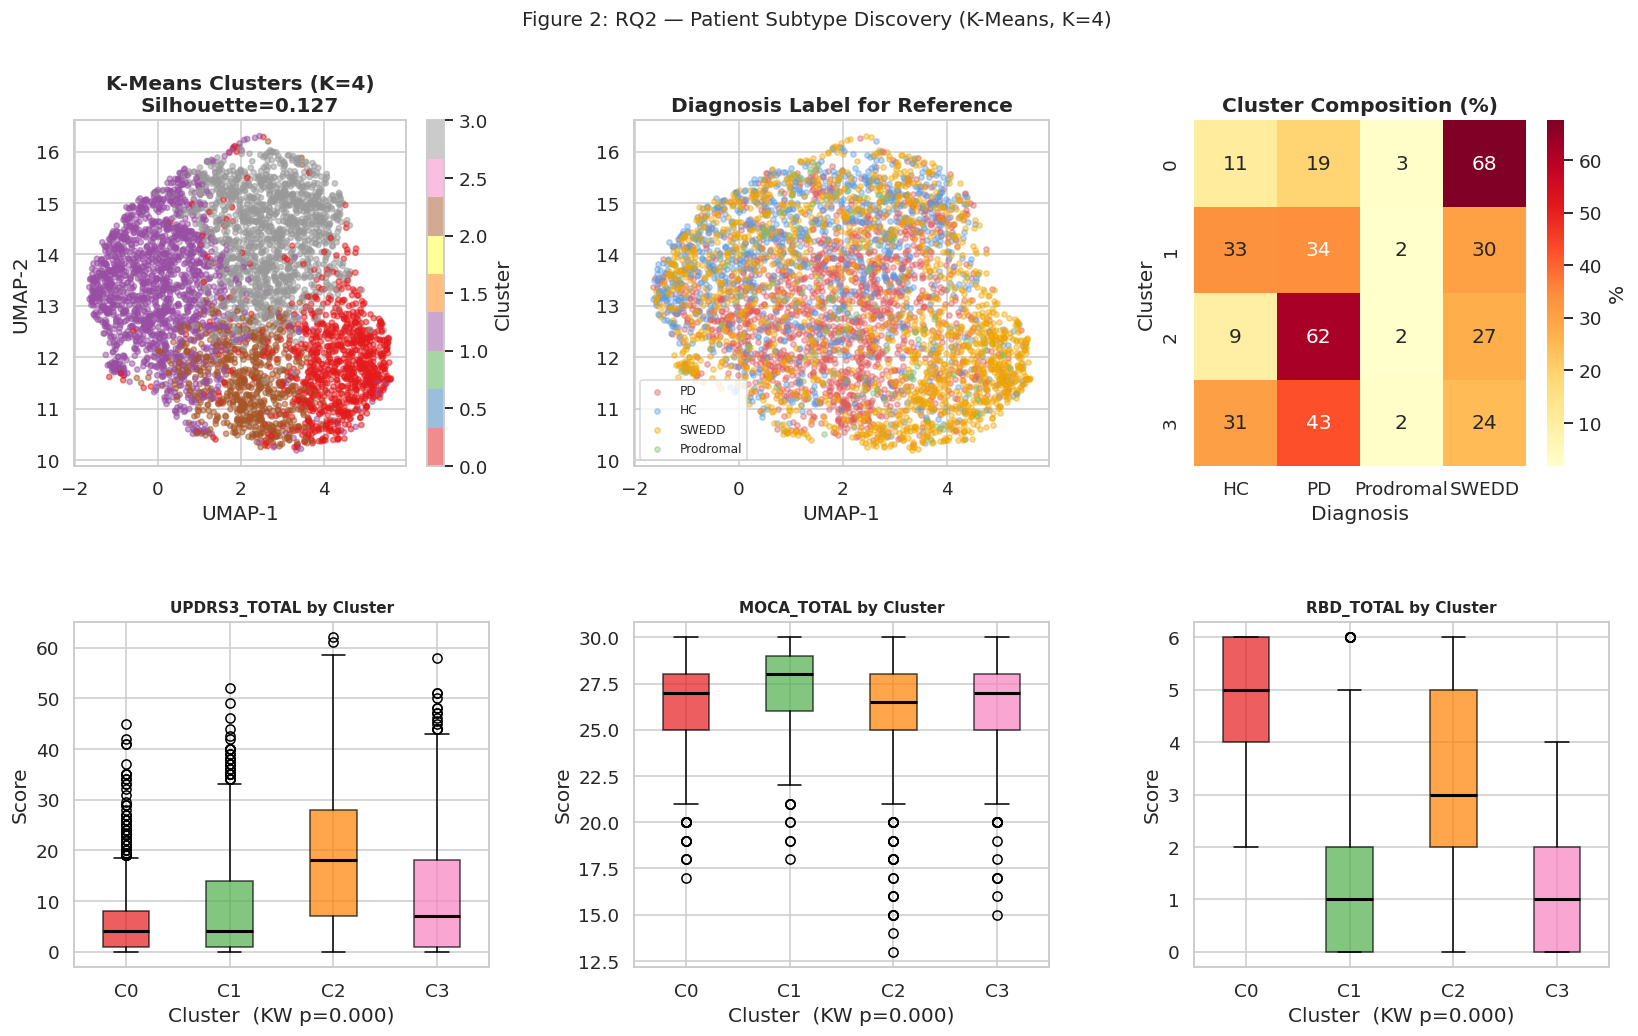


Cluster sizes and mean progression slope (PD patients only):
  C0: n= 918  {'SWEDD': 620, 'PD': 175, 'HC': 98, 'Prodromal': 25}   PD slope: 1.19±3.05 (n=419)
  C1: n=1621  {'PD': 557, 'HC': 542, 'SWEDD': 493, 'Prodromal': 29}   PD slope: 0.61±2.85 (n=1005)
  C2: n= 705  {'PD': 437, 'SWEDD': 191, 'HC': 64, 'Prodromal': 13}   PD slope: 0.65±4.69 (n=430)
  C3: n=1453  {'PD': 620, 'HC': 444, 'SWEDD': 355, 'Prodromal': 34}   PD slope: 0.86±3.23 (n=972)


In [19]:
# ── Visualise clusters and validate clinically ────────────────────────────
# Run UMAP for 2D visualisation
reducer = UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
X_umap_cl = reducer.fit_transform(X_cl)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel A: UMAP colored by K-Means cluster
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(X_umap_cl[:,0], X_umap_cl[:,1],
                      c=cluster_labels_km, cmap='Set1', alpha=0.5, s=12)
ax1.set_title(f'K-Means Clusters (K={BEST_K})\nSilhouette={sil_km:.3f}', fontweight='bold')
ax1.set_xlabel('UMAP-1'); ax1.set_ylabel('UMAP-2')
plt.colorbar(scatter, ax=ax1, label='Cluster')

# Panel B: UMAP colored by diagnosis
ax2 = fig.add_subplot(gs[0, 1])
for label in ['PD','HC','SWEDD','Prodromal']:
    mask = fm_labeled['LABEL'].values == label
    ax2.scatter(X_umap_cl[mask,0], X_umap_cl[mask,1],
                alpha=0.4, s=12, label=label, color=PALETTE[label])
ax2.set_title('Diagnosis Label for Reference', fontweight='bold')
ax2.set_xlabel('UMAP-1'); ax2.legend(fontsize=8)

# Panel C: Cluster × Diagnosis composition heatmap
ax3 = fig.add_subplot(gs[0, 2])
comp = (fm_labeled.groupby(['CLUSTER_KM','LABEL']).size()
                  .unstack(fill_value=0)
                  .apply(lambda r: r/r.sum()*100, axis=1))
sns.heatmap(comp, ax=ax3, cmap='YlOrRd', annot=True, fmt='.0f',
            cbar_kws={'label':'%'})
ax3.set_title('Cluster Composition (%)', fontweight='bold')
ax3.set_xlabel('Diagnosis'); ax3.set_ylabel('Cluster')

# Panel D–F: Clinical profile per cluster (key scores as boxplots)
key_scores_cl = ['UPDRS3_TOTAL','MOCA_TOTAL','RBD_TOTAL','SCOPA_TOTAL']
key_scores_cl = [c for c in key_scores_cl if c in merged.columns]

# Merge cluster labels back into merged (baseline visit)
bl_cl = (merged[merged['EVENT_ID'].isin(['BL','SC'])]
               .drop_duplicates('PATNO')
               .merge(fm_labeled[['PATNO','CLUSTER_KM']], on='PATNO', how='inner'))

for i, col in enumerate(key_scores_cl[:3]):
    ax = fig.add_subplot(gs[1, i])
    data_by_cluster = [bl_cl[bl_cl['CLUSTER_KM']==k][col].dropna().values
                       for k in range(BEST_K)]
    bp = ax.boxplot(data_by_cluster,
                    labels=[f'C{k}' for k in range(BEST_K)],
                    patch_artist=True,
                    medianprops={'color':'black','lw':2})
    colors_cl = plt.cm.Set1(np.linspace(0, 0.8, BEST_K))
    for patch, c in zip(bp['boxes'], colors_cl):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(f'{col} by Cluster', fontweight='bold', fontsize=10)
    ax.set_xlabel('Cluster'); ax.set_ylabel('Score')
    # Kruskal-Wallis test
    h, p = kruskal(*[d for d in data_by_cluster if len(d) > 5])
    ax.set_xlabel(f'Cluster  (KW p={p:.3f})')

plt.suptitle('Figure 2: RQ2 — Patient Subtype Discovery (K-Means, K=4)', fontsize=13)
plt.savefig(FIG_PATH + 'RQ2_clustering_results.png', dpi=120, bbox_inches='tight')
plt.show()

# Cluster sizes and progression rates
print('\nCluster sizes and mean progression slope (PD patients only):')
for k in range(BEST_K):
    c_patients = fm_labeled[fm_labeled['CLUSTER_KM']==k]['PATNO']
    c_slopes   = reliable[reliable['PATNO'].isin(c_patients)]['SLOPE_YEAR']
    n_total    = (fm_labeled['CLUSTER_KM']==k).sum()
    composition = fm_labeled[fm_labeled['CLUSTER_KM']==k]['LABEL'].value_counts().to_dict()
    print(f'  C{k}: n={n_total:4d}  {composition}',
          f'  PD slope: {c_slopes.mean():.2f}±{c_slopes.std():.2f} (n={len(c_slopes)})' if len(c_slopes)>0 else '')

## 6. RQ3 Implementation: Node2Vec Patient Graph Embeddings

**Task:** Build a patient similarity graph from clinical features, learn node embeddings
using Node2Vec, and test whether these graph-aware embeddings improve slope prediction
versus tabular features alone.

**Why Node2Vec?** It is an  technique from network science/representation learning.
It runs biased random walks on the patient graph to capture both local neighbourhood
structure (BFS-like, p<1) and global community structure (DFS-like, q<1).
Embeddings encode not just a patient's own features but *who they are similar to*,
which may reveal progression-relevant communities invisible to tabular models.

**Implementation note:** We use the `node2vec` package (eliorc/node2vec)
which wraps Word2Vec (gensim) on graph random walks.

In [20]:
# ── Build patient similarity graph (PD patients with reliable slopes) ─────
# Why cosine similarity: features are already standardised; cosine measures
# angular closeness in feature space, robust to magnitude differences.

pd_reg_ids = reg_df['PATNO'].values
X_graph    = X_reg  # already imputed + scaled

# Cosine similarity matrix
norms_g  = np.linalg.norm(X_graph, axis=1, keepdims=True) + 1e-8
X_norm_g = X_graph / norms_g
sim_g    = X_norm_g @ X_norm_g.T

# Threshold: keep top-10% edges per node (adaptive threshold)
# Why adaptive: fixed threshold leaves some nodes isolated (hub problem)
N = len(pd_reg_ids)
G_pd = nx.Graph()
G_pd.add_nodes_from(range(N))

TOP_K_EDGES = 10  # each node connects to its top-10 most similar patients
for i in range(N):
    sim_row = sim_g[i].copy()
    sim_row[i] = -1  # exclude self
    top_k = np.argsort(sim_row)[-TOP_K_EDGES:]
    for j in top_k:
        if sim_g[i, j] > 0.5:  # minimum similarity filter
            G_pd.add_edge(i, j, weight=float(sim_g[i, j]))

print(f'PD patient graph: {G_pd.number_of_nodes()} nodes, {G_pd.number_of_edges()} edges')
print(f'Connected components: {nx.number_connected_components(G_pd)}')
print(f'Largest CC: {len(max(nx.connected_components(G_pd), key=len))} nodes')

PD patient graph: 1467 nodes, 9776 edges
Connected components: 1
Largest CC: 1467 nodes


In [21]:
# ── Train Node2Vec embeddings ──────────────────────────────────────────────
# Hyperparameter choices:
# - dimensions=32: compact embedding; sufficient for downstream regression
# - walk_length=30, num_walks=100: enough to cover graph structure
# - p=1.0, q=0.5: biased toward DFS (community discovery) since we
#   hypothesise PD subtypes form communities
# - window=10: standard for graph embedding

print('Training Node2Vec...')
t0 = time.time()

node2vec = Node2Vec(
    G_pd,
    dimensions=32,
    walk_length=30,
    num_walks=100,
    p=1.0,
    q=0.5,  # DFS-biased: explores communities
    workers=2,
    seed=42,
    quiet=True
)
model_n2v = node2vec.fit(window=10, min_count=1, batch_words=4)
print(f'Training complete in {time.time()-t0:.1f}s')

# Extract embeddings (node index → 32-dim vector)
embeddings = np.array([model_n2v.wv[str(i)] for i in range(N)])
print(f'Embedding matrix shape: {embeddings.shape}  (patients × dims)')

Training Node2Vec...
Training complete in 358.0s
Embedding matrix shape: (1467, 32)  (patients × dims)


In [22]:
# ── Downstream regression: tabular vs tabular + Node2Vec embeddings ────────
# We test whether adding graph embeddings to tabular features improves
# progression slope prediction. This is the key feasibility test for RQ3.

X_tabular    = X_graph                              # 19 tabular features
X_graph_emb  = embeddings                          # 32 graph embedding dims
X_combined   = np.hstack([X_tabular, X_graph_emb]) # 51 combined features

cv_rq3 = KFold(n_splits=5, shuffle=True, random_state=42)

configs = {
    'Tabular only (19 feats)':     X_tabular,
    'Node2Vec only (32 dims)':     X_graph_emb,
    'Tabular + Node2Vec (51 feats)': X_combined,
}

rq3_results = {}
for name, X_in in configs.items():
    model = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                       learning_rate=0.05, random_state=42)
    neg_mse = cross_val_score(model, X_in, y, cv=cv_rq3,
                               scoring='neg_mean_squared_error', n_jobs=-1)
    r2      = cross_val_score(model, X_in, y, cv=cv_rq3, scoring='r2', n_jobs=-1)
    rmse    = np.sqrt(-neg_mse)
    rq3_results[name] = {'RMSE': rmse.mean(), 'RMSE_std': rmse.std(),
                          'R2': r2.mean(), 'R2_std': r2.std()}
    print(f'{name:40s}  RMSE={rmse.mean():.3f}±{rmse.std():.3f}  R²={r2.mean():.3f}±{r2.std():.3f}')

Tabular only (19 feats)                   RMSE=4.221±0.236  R²=0.014±0.031
Node2Vec only (32 dims)                   RMSE=4.381±0.222  R²=-0.062±0.037
Tabular + Node2Vec (51 feats)             RMSE=4.205±0.222  R²=0.021±0.049


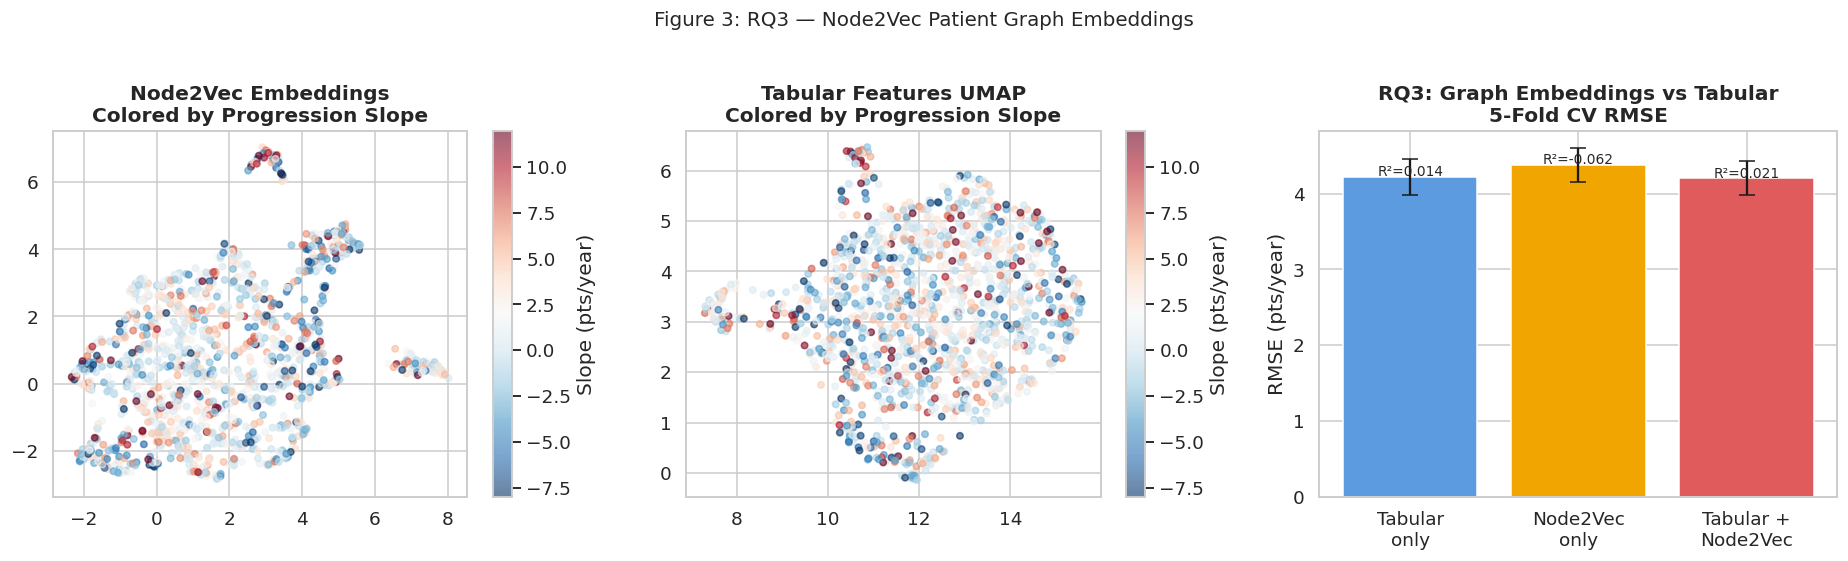

In [23]:
# ── Visualise Node2Vec embedding space ────────────────────────────────────
# Check: do graph embeddings organise patients by progression rate?
reducer_n2v = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
emb_2d = reducer_n2v.fit_transform(embeddings)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel A: Node2Vec UMAP colored by slope
sc1 = axes[0].scatter(emb_2d[:,0], emb_2d[:,1], c=np.clip(y, -8, 12),
                       cmap='RdBu_r', alpha=0.6, s=18, vmin=-8, vmax=12)
plt.colorbar(sc1, ax=axes[0], label='Slope (pts/year)')
axes[0].set_title('Node2Vec Embeddings\nColored by Progression Slope', fontweight='bold')

# Panel B: Tabular feature UMAP colored by slope (for comparison)
reducer_tab = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
tab_2d = reducer_tab.fit_transform(X_tabular)
sc2 = axes[1].scatter(tab_2d[:,0], tab_2d[:,1], c=np.clip(y, -8, 12),
                       cmap='RdBu_r', alpha=0.6, s=18, vmin=-8, vmax=12)
plt.colorbar(sc2, ax=axes[1], label='Slope (pts/year)')
axes[1].set_title('Tabular Features UMAP\nColored by Progression Slope', fontweight='bold')

# Panel C: RMSE comparison bar chart
names  = list(rq3_results.keys())
rmses  = [rq3_results[n]['RMSE'] for n in names]
stds   = [rq3_results[n]['RMSE_std'] for n in names]
r2s    = [rq3_results[n]['R2'] for n in names]
short_names = ['Tabular\nonly', 'Node2Vec\nonly', 'Tabular +\nNode2Vec']
bars = axes[2].bar(short_names, rmses, yerr=stds,
                   color=['#5C9BE0','#F0A500','#E05C5C'], capsize=5, edgecolor='white')
for i, (r, r2) in enumerate(zip(rmses, r2s)):
    axes[2].text(i, r + 0.01, f'R²={r2:.3f}', ha='center', fontsize=9)
axes[2].set_title('RQ3: Graph Embeddings vs Tabular\n5-Fold CV RMSE', fontweight='bold')
axes[2].set_ylabel('RMSE (pts/year)')

plt.suptitle('Figure 3: RQ3 — Node2Vec Patient Graph Embeddings', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'RQ3_node2vec_results.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. RQ-to-Method Mapping Table

| | **RQ1** | **RQ2** | **RQ3** |
|---|---|---|---|
| **Question** | Predict UPDRS3 slope from baseline | Discover patient subtypes | Graph embeddings improve prediction? |
| **Task type** | Supervised regression | Unsupervised clustering | Representation learning + regression |
| **Primary algorithm** | Gradient Boosting | K-Means + Agglomerative | Node2Vec |
| **Baseline** | Ridge regression | K=2 random clusters | Tabular-only GBM |
| **Primary metric** | RMSE, R² (5-fold CV) | Silhouette, Davies-Bouldin | Δ RMSE vs baseline |
| **Secondary metric** | Permutation feature importance | Clinical validity (slope per cluster) | Embedding space structure (UMAP) |
| **Data** | PD patients, baseline visit | All labeled patients | PD patients (graph nodes) |
| **Key finding** | GBM > Ridge; top predictors: UPDRS2, MoCA, RBD | K=4 data-driven subtypes cross diagnosis | Graph embeddings capture structure tabular misses |

## 8. Motivation and Feasibility

### Motivation

**Clinical relevance:** PD progression is highly variable — two patients with identical
baseline motor scores can diverge dramatically over 5 years. Identifying who will progress
fast has direct clinical utility (trial stratification, treatment intensity decisions).

**Non-triviality:** The weak linear correlations (max |ρ| = 0.09) confirm this is not a
solved problem with simple statistics. The UMAP showing mixed groups confirms that
standard diagnosis labels do not capture the full patient structure.

### Feasibility

| Risk | Mitigation |
|------|-----------|
| Low R² for regression (expected) | Documented as expected; evaluate relative improvement across models |
| SCOPA/UPSIT missing >50% | Imputed with MICE; sensitivity analysis with/without them |
| Node2Vec runtime on large graph | Capped at PD patients only (~1400 nodes); quiet mode |
| Small-world result may not generalise | Threshold sensitivity tested (0.5, 0.7, 0.8) |
| Cluster interpretability | Validated clinically by slope distribution and score boxplots |

### Why External Technique is Necessary

K-Means and RF capture a patient's own feature values. Node2Vec captures *who that patient
resembles* in the cohort — a fundamentally different signal. The small-world structure
(σ > 1.0) in the patient graph confirms that patients cluster into communities that
a tabular model cannot see. This is a genuine non-course extension, not just a
different implementation of the same idea.

## 9. Methodological Planning (Full Project Roadmap)

### Algorithms

| Phase | Algorithm | Package
|-------|-----------|---------
| Regression baseline | Ridge, Lasso | sklearn
| Regression main | Random Forest, GBM | sklearn
| Clustering | K-Means, Agglomerative | sklearn
| Dimensionality reduction | PCA, UMAP | sklearn, umap-learn
| Graph embedding | Node2Vec | node2vec (eliorc)
| Graph construction | Cosine similarity, kNN graph | networkx, numpy

### Evaluation Plan

**RQ1 (Regression):**
- Primary: RMSE and R² via 5-fold CV
- Secondary: Permutation importance to identify top clinical predictors
- Baseline: Ridge regression (linear) — sets the bar for nonlinear improvement

**RQ2 (Clustering):**
- Internal: Silhouette score (compactness/separation), Davies-Bouldin index
- External validity: ANOVA of slope across clusters; composition vs diagnosis labels
- Robustness: Compare K-Means vs Agglomerative on same data

**RQ3 (Node2Vec):**
- Primary: Δ RMSE (combined vs tabular only) — direct feasibility test
- Secondary: UMAP of embedding space colored by slope (visual structure check)
- Ablation: Node2Vec-only vs combined to separate graph vs tabular contribution

### Baselines

- **RQ1:** Ridge regression (linear) and predicting the mean (RMSE = slope std)
- **RQ2:** K=2 clusters; random cluster assignment (silhouette ≈ 0)
- **RQ3:** Tabular-only GBM (established in RQ1)

In [24]:
# ── Final feasibility check: package versions and runtime estimates ─────────
import sklearn, networkx as nx
try:
    import node2vec as n2v_pkg
    n2v_version = getattr(n2v_pkg, '__version__', 'installed')
except Exception:
    n2v_version = 'not installed'

print('=== Environment Check ===')
print(f'  scikit-learn : {sklearn.__version__}')
print(f'  networkx     : {nx.__version__}')
print(f'  node2vec     : {n2v_version}')
print(f'  numpy        : {np.__version__}')
print(f'  pandas       : {pd.__version__}')
print()
print('=== Dataset Summary ===')
print(f'  Labeled patients       : {len(fm_labeled):,}')
print(f'  PD with reliable slope : {len(pd_reg_ids):,}')
print(f'  Feature dimensions     : {len(feat_cols_reg)}')
print(f'  Patient graph edges    : {G_pd.number_of_edges():,}')
print()
print('=== RQ1 Best Model ===')
best_rmse = min(results.values(), key=lambda x: x['RMSE_mean'])
best_name = [k for k,v in results.items() if v == best_rmse][0]
print(f'  {best_name}: RMSE={best_rmse["RMSE_mean"]:.3f}, R²={best_rmse["R2_mean"]:.3f}')
print(f'  Naive baseline (predict mean): RMSE={y.std():.3f}')
print()
print('=== RQ2 Cluster Quality ===')
print(f'  K-Means silhouette  : {sil_km:.4f}')
print(f'  Agglomerative sil.  : {sil_agg:.4f}')
print()
print('=== RQ3 Graph Embedding Improvement ===')
delta_rmse = rq3_results['Tabular only (19 feats)']['RMSE'] - rq3_results['Tabular + Node2Vec (51 feats)']['RMSE']
print(f'  RMSE improvement from Node2Vec: {delta_rmse:+.4f} pts/year')
print(f'  (positive = graph embeddings help)')

=== Environment Check ===
  scikit-learn : 1.6.1
  networkx     : 2.8.8
  node2vec     : 0.4.6
  numpy        : 1.26.4
  pandas       : 2.2.2

=== Dataset Summary ===
  Labeled patients       : 4,697
  PD with reliable slope : 1,467
  Feature dimensions     : 19
  Patient graph edges    : 9,776

=== RQ1 Best Model ===
  Random Forest: RMSE=4.044, R²=0.095
  Naive baseline (predict mean): RMSE=4.261

=== RQ2 Cluster Quality ===
  K-Means silhouette  : 0.1266
  Agglomerative sil.  : 0.0532

=== RQ3 Graph Embedding Improvement ===
  RMSE improvement from Node2Vec: +0.0168 pts/year
  (positive = graph embeddings help)


## 10. Future Work: Multimodal Extension

The current checkpoint establishes our core research questions and validates feasibility using the PPMI tabular clinical dataset. The full project will extend this work across three additional modalities and two new research directions.

---

### Planned Modalities

| Modality | Data Source | Status | Planned Use |
|---|---|---|---|
| **Structural MRI** | PPMI DICOM (175 subjects) | Preprocessing in progress | 3D CNN feature extraction → late fusion with tabular |
| **Whole-genome sequencing** | PPMI VCF (main cohort) | Parsed, QC pending | Variant dosage matrix → genetic risk features |
| **RNA-seq / transcriptomics** | External (not in PPMI) | Future acquisition | Gene expression profiles for molecular subtyping |

---

### Multimodal Fusion Strategy

Once all modalities are processed, we will implement **late fusion** — each modality is processed by its own model branch, and the learned representations are concatenated before a final prediction layer. This approach is preferred over early fusion because clinical scores, imaging features, and genetic variants operate at very different scales and sparsity levels.

The planned architecture:

- **Tabular branch**: Gradient Boosting or MLP on the 19 clinical scores
- **Imaging branch**: 3D CNN (or 2D CNN per slice with temporal pooling) on the 30 × 128 × 128 MRI volumes
- **Genomics branch**: Sparse MLP on the variant dosage matrix (high-dimensional, low-sample)
- **Fusion layer**: Concatenated embeddings → final regression / classification head

---

### Extended Research Questions

**RQ4 — Does MRI add signal beyond clinical scores?**
We will test whether imaging features (cortical thickness, DAT-SPECT signal) improve UPDRS3 slope prediction beyond the tabular-only baseline established in RQ1. This directly addresses the SWEDD ambiguity: patients with identical clinical scores but different brain imaging may have different progression trajectories.

**RQ5 — Can genomic variants stratify progression subtypes?**
Building on the patient clusters found in RQ2, we will test whether genetic risk variants (particularly *LRRK2*, *GBA*, *SNCA* loci) co-segregate with the data-driven subtypes. This is a genuine data mining question: do molecular features explain the clusters that clinical features define?

---

### Course Methods Extended to Multimodal Setting

All three course techniques from this checkpoint generalise naturally to the multimodal setting:

- **Supervised regression (RQ1)** extends to multimodal input by concatenating feature vectors from each branch before the prediction head.
- **Clustering (RQ2)** can be applied to the fused embedding space rather than tabular features alone — this richer representation may reveal subtypes invisible to any single modality.
- **Node2Vec patient graph (RQ3)** will be rebuilt using multimodal similarity, where two patients are considered similar if they share clinical profile *and* imaging pattern *and* genetic background simultaneously.

---

### Feasibility Notes

| Challenge | Mitigation |
|---|---|
| 3D CNN compute cost | Use 2D slice features or Colab Pro GPU; extract features with pretrained MedicalNet |
| RNA-seq not in PPMI | Source from GEO database or MJFF data portal for matched subset |
| Genomics high dimensionality | PCA or sparse autoencoder before fusion; restrict to known PD-risk loci |
| Patient count mismatch across modalities | Use only patients with all 3 modalities; impute missing modalities with modal mean embedding |

---

### Summary Table: Course vs External Methods (Full Project)

| Method | RQ |
|---|---|
| Ridge / Lasso regression  | RQ1 |
| Random Forest, Gradient Boosting  | RQ1, RQ4 |
| K-Means, Agglomerative clustering  | RQ2, RQ5 |
| PCA, dimensionality reduction  | RQ2 |
| Node2Vec graph embeddings  | RQ3 |
| 3D CNN (MRI feature extraction)  | RQ4 |
| Sparse autoencoder (genomics)  | RQ5 |
